In [1]:
# regresssão supervisionada 
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR 
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.neural_network import MLPRegressor

In [2]:
# análise de dados e avaliação do modelo
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2, f_regression

In [3]:
# deep learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.optimizers import SGD
from scikeras.wrappers import KerasRegressor

In [4]:
# séries temporais
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm 

In [5]:
import numpy as np
import pandas as pd
import yfinance as yf
import pandas_datareader.data as web
from datetime import datetime, timedelta
import seaborn as sns
from matplotlib import pyplot
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf


In [6]:
stk_tickers = ['MSFT', 'IBM', 'GOOGL']
ccy_tickers = ['DEXJPUS', 'DEXUSUK']
idx_tickers = ['SP500', 'DJIA', 'VIXCLS']

data_inicio = datetime.today() - timedelta(days=3650) #10 anos atrás
data_fim = datetime.today().strftime("%Y-%m-%d")

stk_data = yf.download(stk_tickers, start=data_inicio, end=data_fim, auto_adjust=True)
ccy_data = web.DataReader(ccy_tickers, 'fred', start=data_inicio, end=data_fim)
idx_data = web.DataReader(idx_tickers, 'fred', start=data_inicio, end=data_fim)

return_period = 5
Y = np.log(stk_data.loc[:, ('Close', 'MSFT')]).diff(return_period).shift(-return_period)
Y.name = 'MSFT_pred'

X1 = np.log(stk_data.loc[:, ('Close', ('GOOGL', 'IBM'))]).diff(return_period)
X1.columns = X1.columns.droplevel(0)

X2 = np.log(ccy_data).diff(return_period)
X3 = np.log(idx_data).diff(return_period)   

X4 = pd.concat([np.log(stk_data.loc[:, ('Close', 'MSFT')]).diff(i) for i in [return_period, return_period*3, return_period*6, return_period*12]], axis=1).dropna()
X4.columns = ['MSFT_DT', 'MSFT_3DT', 'MSFT_6DT', 'MSFT_12DT']

X = pd.concat([X1, X2, X3, X4], axis=1)
dataset = pd.concat([X, Y], axis=1).dropna().iloc[::return_period, :]

Y = dataset.loc[:, 'MSFT_pred']
X = dataset.drop(columns=['MSFT_pred'])

dataset.head()


[*********************100%***********************]  3 of 3 completed
C:\Users\Usuario\AppData\Local\Temp\ipykernel_15116\2700341667.py:25: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  X = pd.concat([X1, X2, X3, X4], axis=1)


,GOOGL,IBM,DEXJPUS,DEXUSUK,SP500,DJIA,VIXCLS,MSFT_DT,MSFT_3DT,MSFT_6DT,MSFT_12DT,MSFT_pred
2016-10-11,0.008410,-0.010731,0.006795,-0.042307,-0.006419,-0.002192,0.119493,-0.000874,0.006667,-0.015786,0.064349,0.008185
2016-10-19,0.018394,-0.019834,-0.011358,0.006864,0.002386,0.003215,-0.099025,0.007327,-0.008654,-0.002257,0.019688,0.052483
2016-10-26,-0.005749,0.003629,0.010784,-0.003672,-0.002269,-0.000181,-0.011868,0.052483,0.050573,0.074806,0.075347,-0.019991
2016-11-02,-0.041831,0.000922,-0.011559,0.006599,-0.019584,-0.013258,0.305086,-0.019991,0.039819,0.028503,0.027127,0.012375
2016-11-09,0.021544,0.027678,0.015573,0.012828,0.030660,0.034480,-0.295302,0.012375,0.044867,0.036213,0.046433,-0.001947


<Axes: title={'center': 'Correlation Matrix'}>

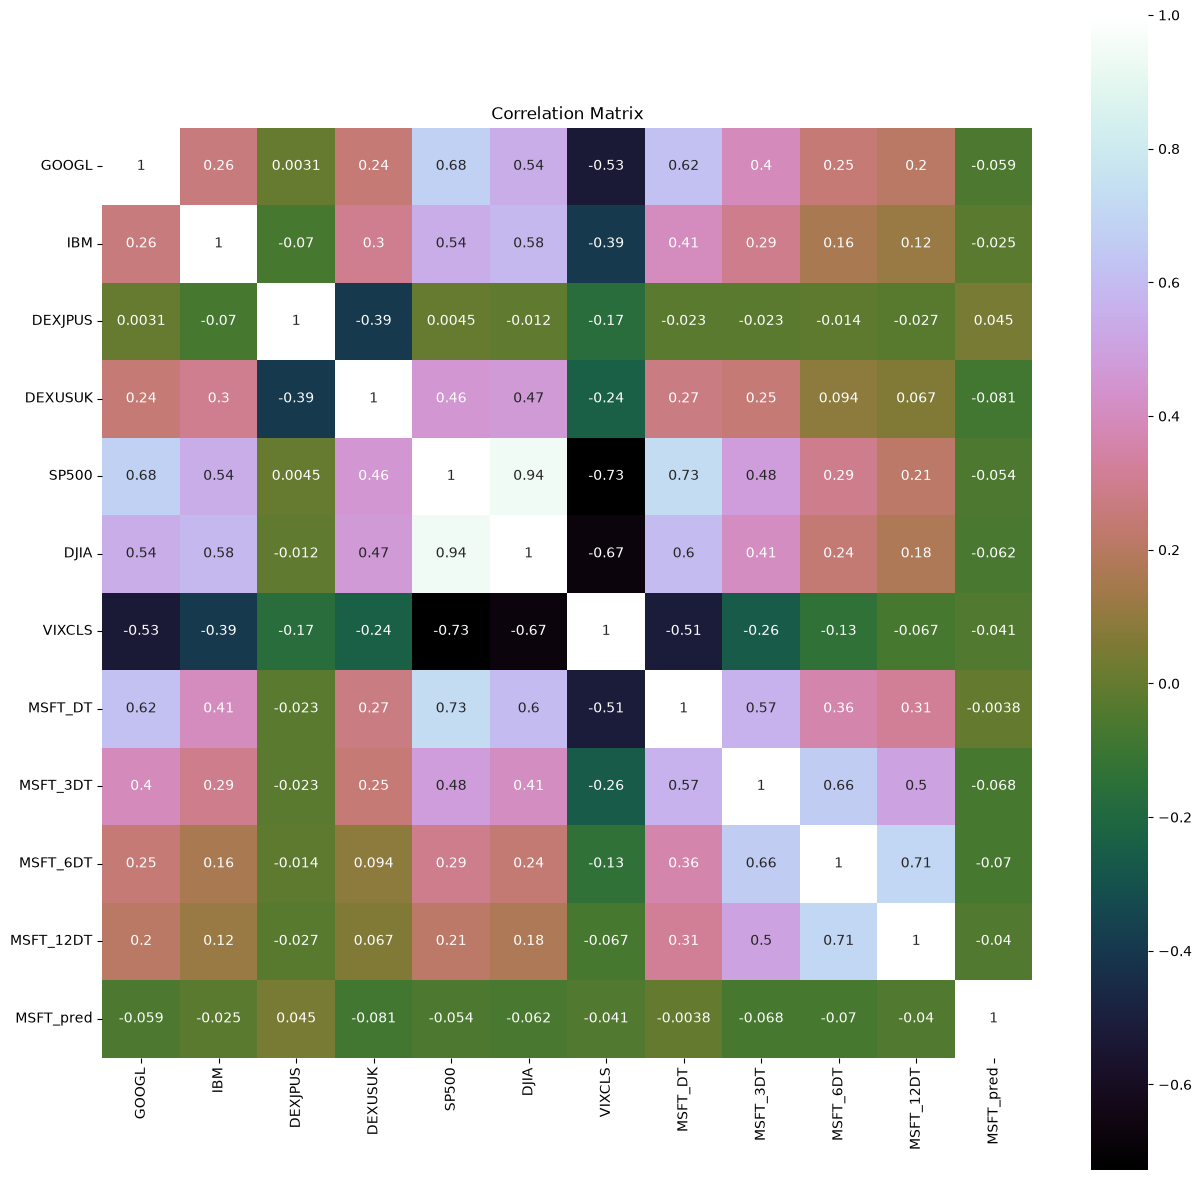

In [7]:
# visualization
correlation = dataset.corr()
pyplot.figure(figsize=(15,15))
pyplot.title('Correlation Matrix')
sns.heatmap(correlation, vmax=1, square=True, annot=True, cmap='cubehelix')


<Figure size 1500x1500 with 0 Axes>

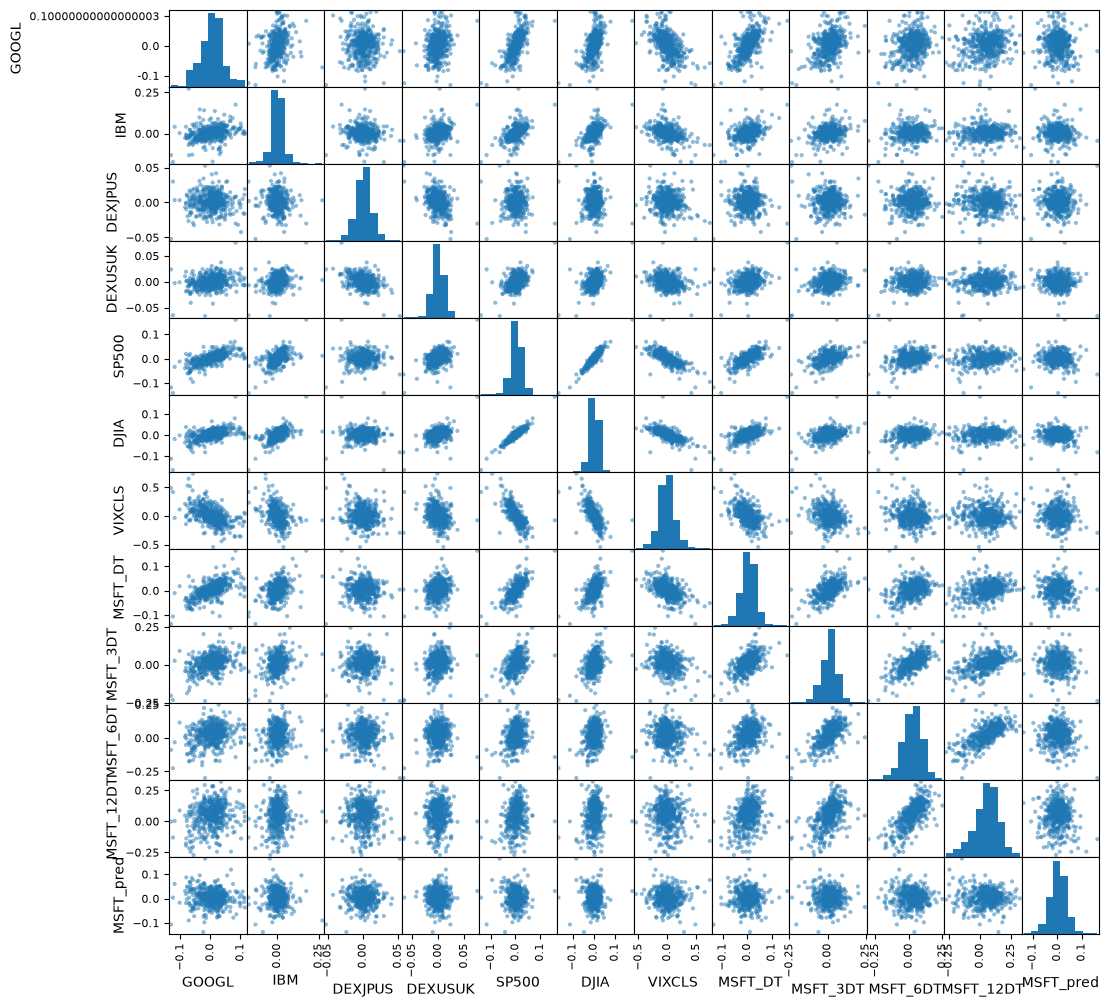

In [8]:
# adpating for a scatter plot

pyplot.figure(figsize=(15,15))
scatter_matrix(dataset, figsize=(12,12))
pyplot.show()

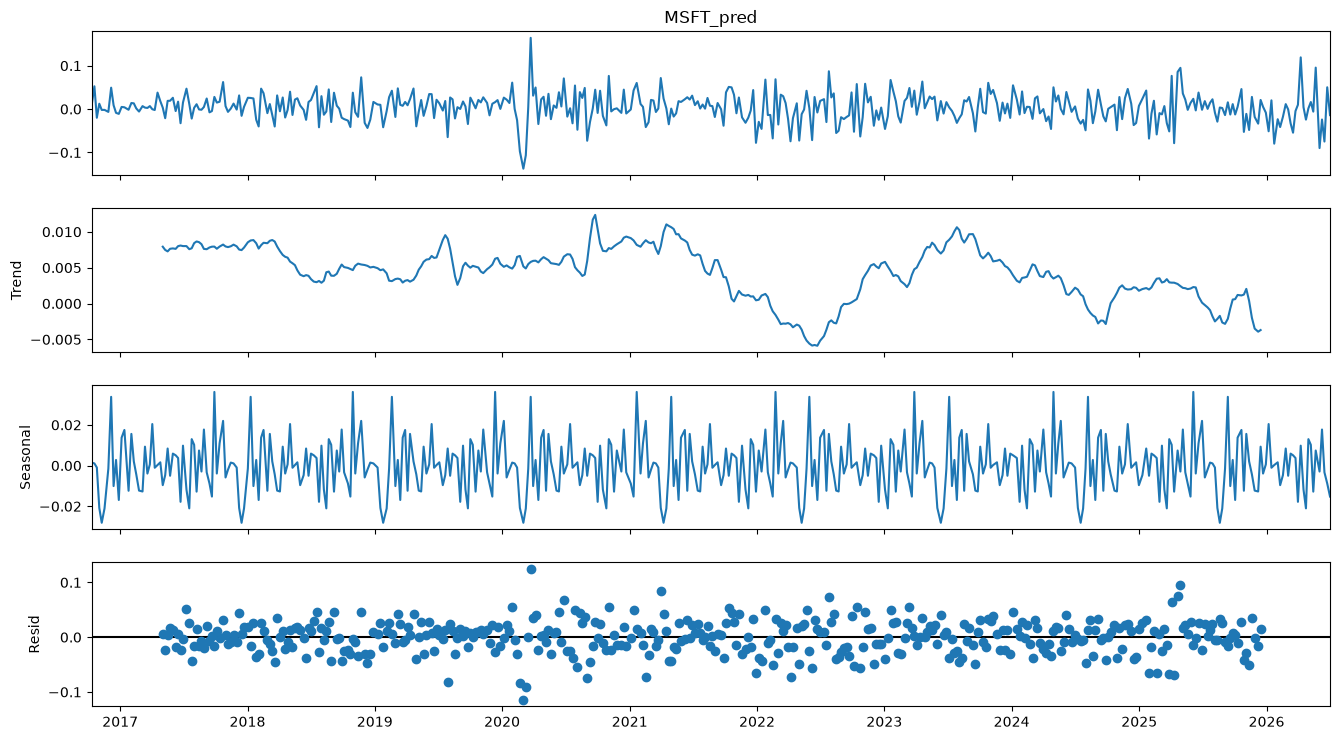

In [9]:
res = sm.tsa.seasonal_decompose(Y, period=52)
fig = res.plot()
fig.set_figheight(8)
fig.set_figwidth(15)
pyplot.show()


In [10]:
# train-test split and evaluation metrics
validation_size = 0.2 # dados para teste
train_size = int(len(X) * (1-validation_size))
X_train, X_test = X[0:train_size], X[train_size:len(X)]
Y_train, Y_test = Y[0:train_size], Y[train_size:len(X)]

# cross validation (otimizar hiperparâmetros do modelo) - CV dez vezes e calculamos dez vezes para obter a aleatoriedade
# avaliação (erro quadrático médio) - performance dos modelos de regressão supervisionada
num_folds = 10
scoring = 'neg_mean_squared_error' 


In [11]:
# Machine learning (sklearn)
# regressão e árvore de regressão
models = []
models.append(('LR', LinearRegression()))
models.append(('LASSO', Lasso()))
models.append(('EN', ElasticNet()))
models.append(('KNN', KNeighborsRegressor()))
models.append(('CART', DecisionTreeRegressor()))
models.append(('SVR', SVR()))

# neural ntws
models.append(('MLP', MLPRegressor()))

# ensemble -> boosting
models.append(('ABR', AdaBoostRegressor()))
models.append(('GBR', GradientBoostingRegressor()))

# ensemble -> bagging
models.append(('RFR', RandomForestRegressor()))
models.append(('ETR', ExtraTreesRegressor()))

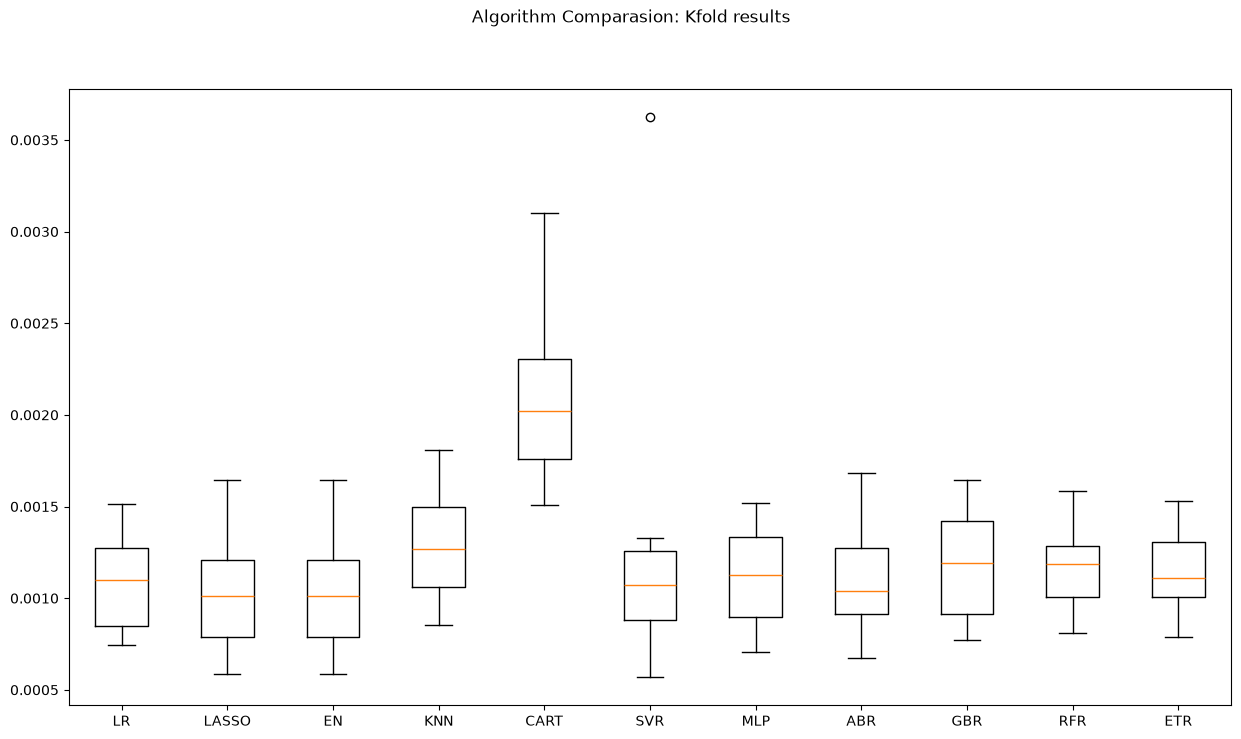

In [12]:
# análise k-fold e execução do modelo com os conjuntos de dados completos de treinamento e de teste
names = []
kfold_results = []
test_results = []
train_results = []

for name, model in models:
    names.append(name)
    # análise k-fold
    kfold = KFold(n_splits=num_folds, shuffle=True, random_state=42)
    # erro quadrático positivo, menor = melhor
    cv_results = -1 * cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
    kfold_results.append(cv_results)
    # periodo completo de treinamento
    res = model.fit(X_train, Y_train)
    train_result = mean_squared_error(res.predict(X_train), Y_train)
    train_results.append(train_result)
    # resultados dos testes
    test_result = mean_squared_error(res.predict(X_test), Y_test)
    test_results.append(test_result)

# results (cross validation)
fig = pyplot.figure()
fig.suptitle('Algorithm Comparasion: Kfold results')
ax = fig.add_subplot(111)
pyplot.boxplot(kfold_results)
ax.set_xticklabels(names)
fig.set_size_inches(15,8)
pyplot.show()


OBS: Lasso, EN, SVR melhores resultados

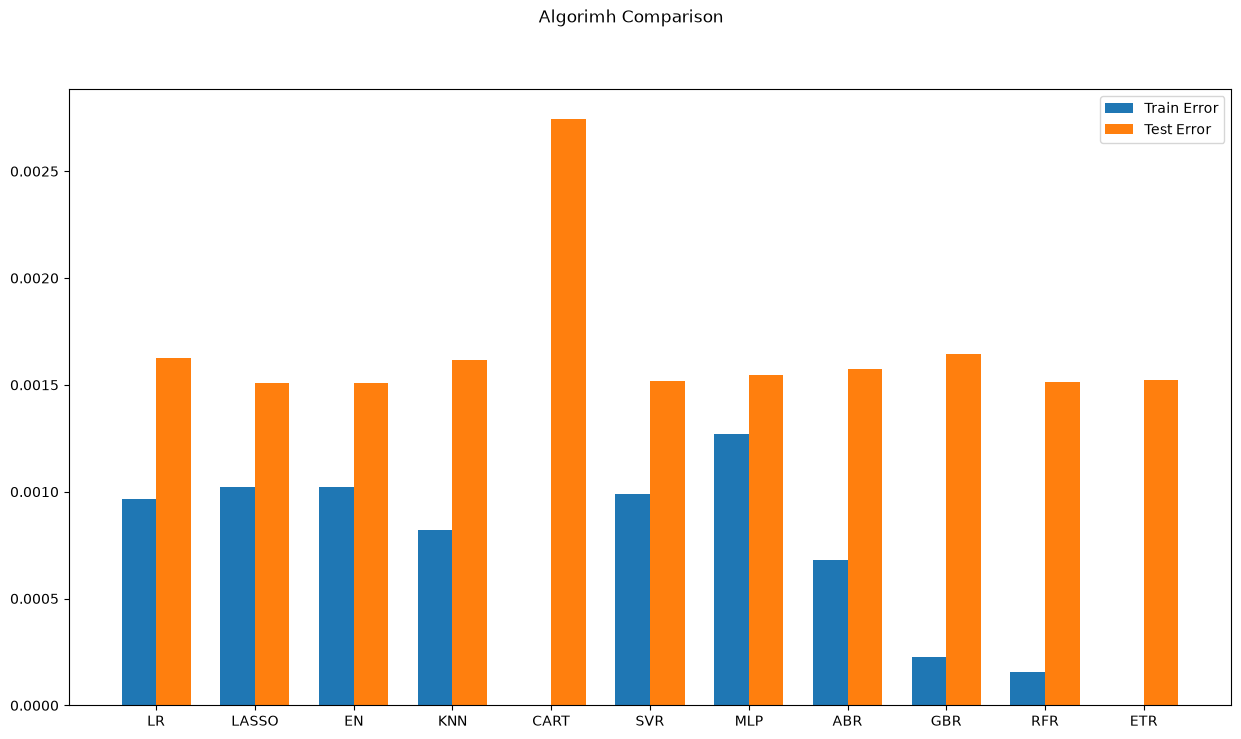

In [13]:
# erro de treinamento e teste
# comparação de algorítimos
fig = pyplot.figure()
ind = np.arange(len(names)) # localidades x para os grupos
width = 0.35 # com a largura das barras

fig.suptitle('Algorimh Comparison')
ax = fig.add_subplot(111)
pyplot.bar(ind - width/2, train_results, width=width, label='Train Error')
pyplot.bar(ind + width/2, test_results, width=width, label='Test Error')
fig.set_size_inches(15,8)
pyplot.legend()
ax.set_xticks(ind)
ax.set_xticklabels(names)
pyplot.show()

### Time Series based in ARIMA and LSTM

In [14]:
# preparing the data for the ARIMA model
# apenas variaveis correlacionadas como variaveis exogenas 
X_train_ARIMA = X_train.loc[:, ['GOOGL', 'IBM', 'DEXJPUS', 'SP500', 'DJIA', 'VIXCLS']]
X_test_ARIMA = X_test.loc[:, ['GOOGL', 'IBM', 'DEXJPUS', 'SP500', 'DJIA', 'VIXCLS']]
tr_len = len(X_train_ARIMA)
ts_len = len(X_test_ARIMA)
to_len = len(X)

# ARIMA com ordem (1,0,0), variaveis independetes como variaveis exogenas (ARIMAX)
modelARIMA = ARIMA(endog=Y_train, exog=X_train_ARIMA, order=(1,0,0))
model_fit = modelARIMA.fit() # fit() encontra padrões (machine learning)

error_training_ARIMA = mean_squared_error(Y_train, model_fit.fittedvalues) 
predicted = model_fit.predict(start= tr_len -1, end= to_len -1, exog= X_test_ARIMA)[1:]
error_test_ARIMA = mean_squared_error(Y_test, predicted)
error_test_ARIMA

c:\Users\Usuario\Documents\time-series-project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Usuario\Documents\time-series-project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Usuario\Documents\time-series-project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Usuario\Documents\time-series-project\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization fai

0.0015087307872859192

c:\Users\Usuario\Documents\time-series-project\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


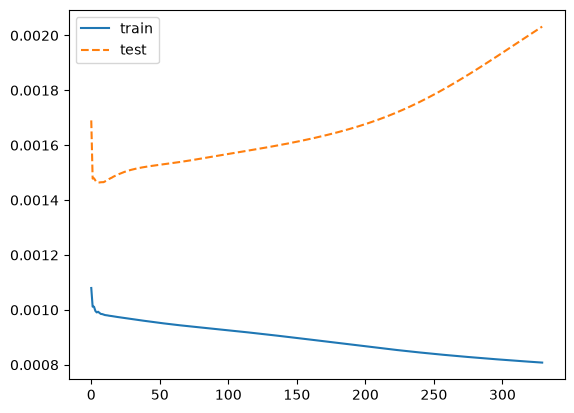

In [15]:
# LSTM model
seq_len = 2 # comprimento do seq para o LSTM

Y_train_LSTM, Y_test_LSTM = np.array(Y_train)[seq_len -1:], np.array(Y_test)
X_train_LSTM = np.zeros((X_train.shape[0] +1 -seq_len, seq_len, X_train.shape[1]))
X_test_LSTM = np.zeros((X_test.shape[0], seq_len, X.shape[1]))

for i in range(seq_len):
    X_train_LSTM[:, i, :] = np.array(X_train)[i:X_train.shape[0] +i +1 -seq_len, :]
    X_test_LSTM[:, i, :] = np.array(X)[X_train.shape[0] +i +1 -seq_len, :]

# LSTM network
def create_LSTMmodel(learn_rate = 0.01, momentum =0):
    model = Sequential()
    model.add(LSTM(50, input_shape=(X_train_LSTM.shape[1], X_train_LSTM.shape[2])))

    model.add(Dense(1))
    optimizer = SGD(learning_rate= learn_rate, momentum= momentum)
    model.compile(loss= 'mse', optimizer= 'adam')
    return model

LSTMModel = create_LSTMmodel(learn_rate = 0.01, momentum = 0.0)
LSTMModel_fit = LSTMModel.fit(X_train_LSTM, Y_train_LSTM, validation_data=(X_test_LSTM, Y_test_LSTM), epochs= 330, batch_size= 72, verbose= 0, shuffle= False)

pyplot.plot(LSTMModel_fit.history['loss'], label= 'train')
pyplot.plot(LSTMModel_fit.history['val_loss'], '--', label= 'test')
pyplot.legend()
pyplot.show()



In [16]:
error_training_LSTM = mean_squared_error(Y_train_LSTM, LSTMModel.predict(X_train_LSTM))
predicted = LSTMModel.predict(X_test_LSTM)
error_test_LSTM = mean_squared_error(Y_test, predicted)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [17]:
# comparing model results
test_results.append(error_test_ARIMA)
test_results.append(error_test_LSTM)

train_results.append(error_training_ARIMA)
train_results.append(error_training_LSTM)

names.append("ARIMA")
names.append("LSTM")

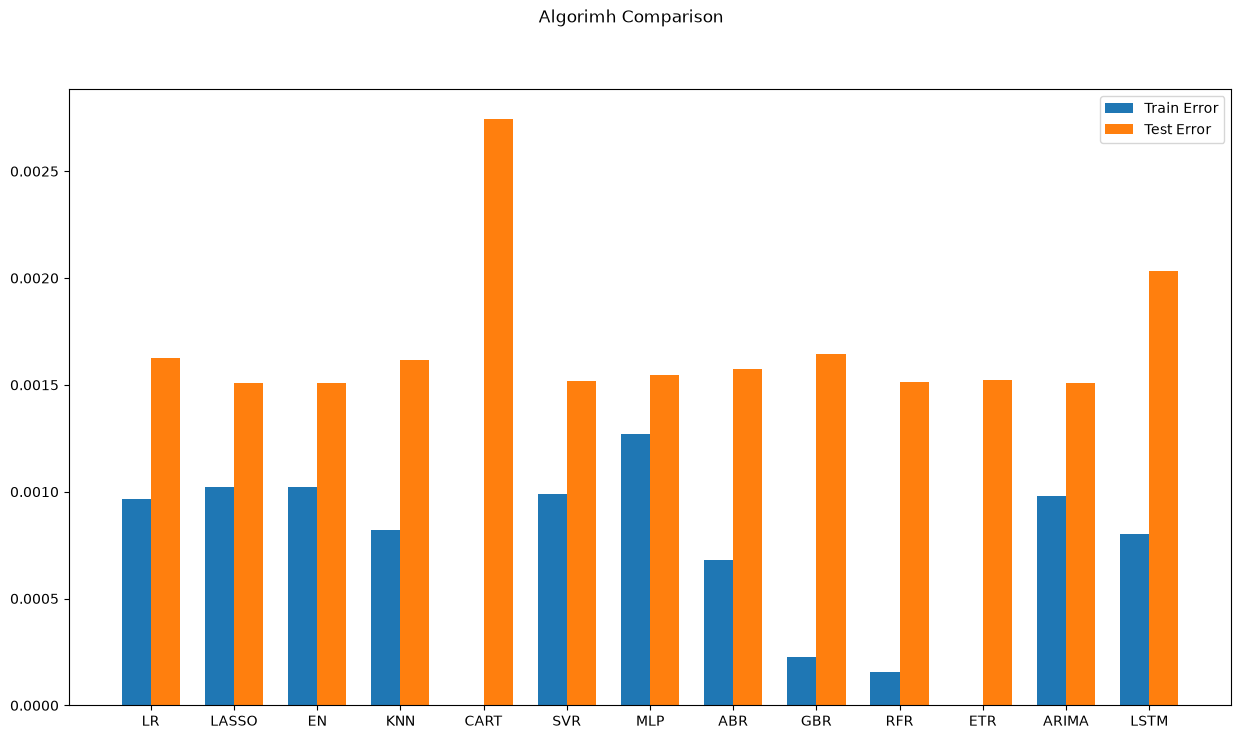

In [23]:
fig = pyplot.figure()
ind = np.arange(len(names)) # localidades x para os grupos
width = 0.35 # com a largura das barras

fig.suptitle('Algorimh Comparison')
ax = fig.add_subplot(111)
pyplot.bar(ind - width/2, train_results, width=width, label='Train Error')
pyplot.bar(ind + width/2, test_results, width=width, label='Test Error')
fig.set_size_inches(15,8)
pyplot.legend()
ax.set_xticks(ind)
ax.set_xticklabels(names)
pyplot.show()

Interpretação

train < test - overfitting\
test < train - regularização, calibrado\
train =~ test (ambos baixos) - ideal, boa generalização\

Objetivo: Calibrar modelos ARIMA e LSTM e otimizar hiperparâmetros dos modelos, visto que o test error obtido foi de ^0.0015